# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [24]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt


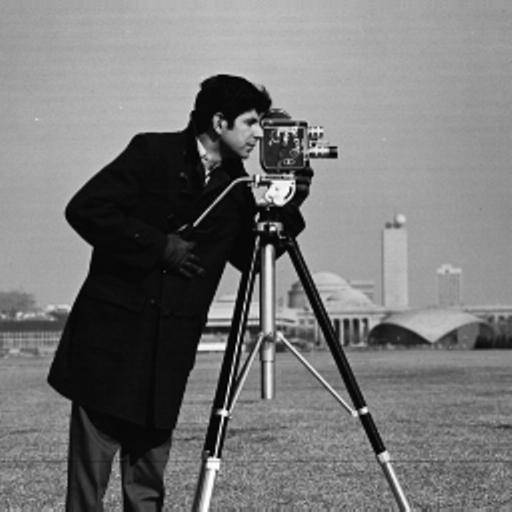

In [25]:
# Load image
image = Image.open("input_image.jpg").convert("L")
display(image)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [26]:
# Get the size of the image
width, height = image.size

# Scaling factors
scale_x = 2
scale_y = 2

print("Original size:", (width, height))
print("New size:", (width * scale_x, height * scale_y))


Original size: (512, 512)
New size: (1024, 1024)


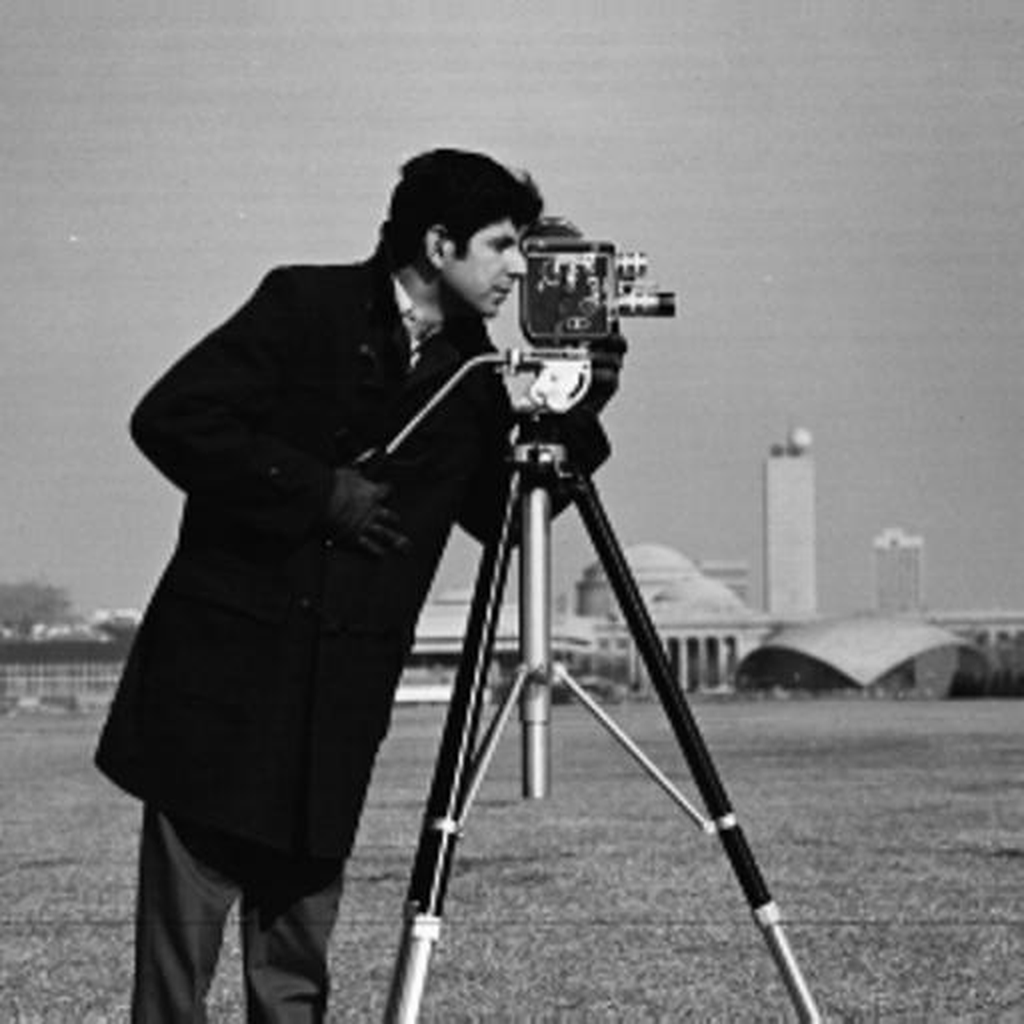

In [27]:
# ── 1. Increase size (scale ×2) ────────────────────
# Resize the image using PIL's built-in method
scaled_image = image.resize(
    (width * scale_x, height * scale_y),
    Image.Resampling.LANCZOS
)

display(scaled_image)


In [28]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_image.save("task1_1_scaled.jpg")

print("Original size:", image.size)
print("Scaled size:", scaled_image.size)

Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

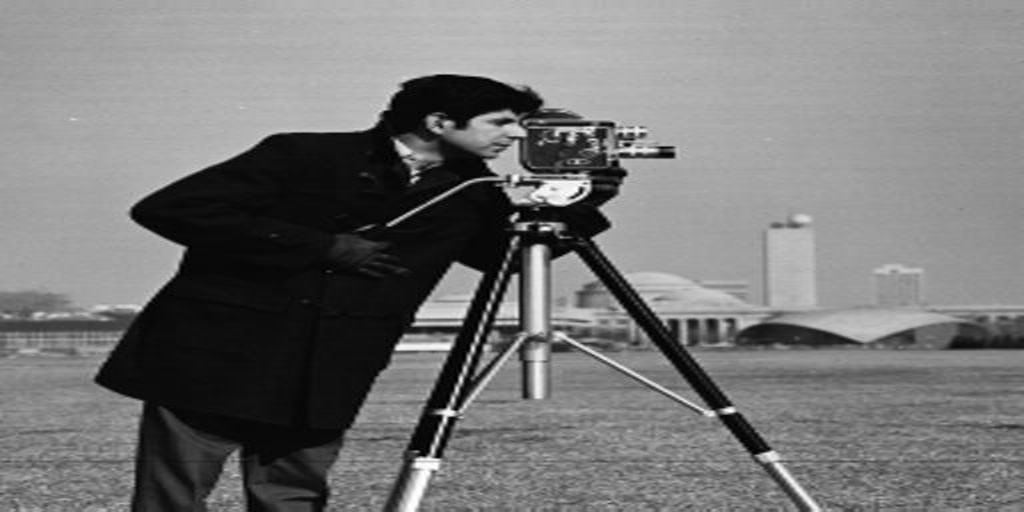

In [29]:
cx = 2
cy = 1

non_uniform_image = image.resize(
    (int(width * cx), int(height * cy)),
    Image.Resampling.LANCZOS
)

display(non_uniform_image)

In [30]:
print("Original size:", image.size)
print("Non-uniform scaled size:", non_uniform_image.size)

Original size: (512, 512)
Non-uniform scaled size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

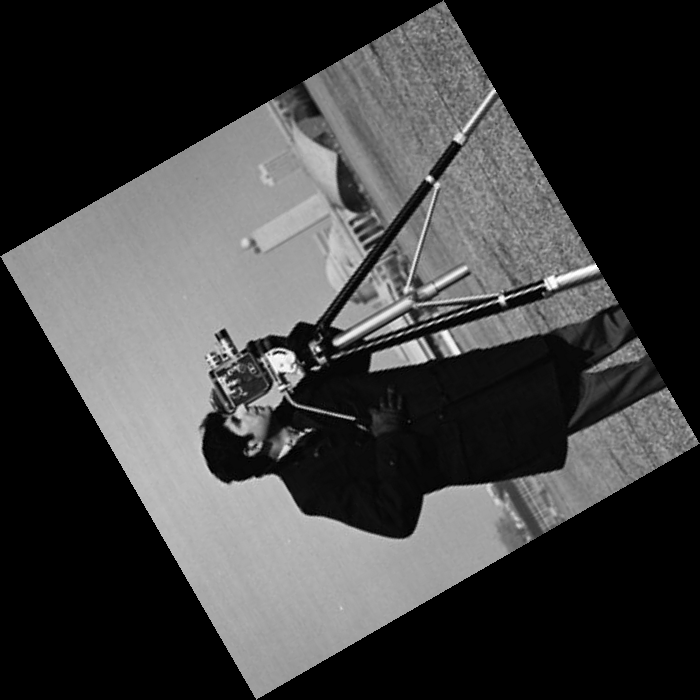

Original size: (512, 512)
Rotated size: (700, 700)


In [31]:
# ── 2. Rotate 120 degrees 
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_image = image.rotate(
    120,
    resample=Image.Resampling.BICUBIC,
    expand=True
)

display(rotated_image)

# Save the rotated image
rotated_image.save("task1_2_rotated.jpg")

print("Original size:", image.size)
print("Rotated size:", rotated_image.size)

### 3. Shear

In [32]:
# -- c. Get the image dimensions ────────────────────
width, height = image.size
print("Image dimensions:", width, "x", height)


Image dimensions: 512 x 512


In [33]:
# -- d. Define the shear matrix ─────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5

shx = shear_factor
shy = 0

# PIL Image.transform() expects the inverse affine transform.
# For x' = x + shx*y, the inverse is x = x' - shx*y'.
shear_matrix = (1, -shx, 0, 0, 1, 0)

print("Shear factor:", shear_factor)
print("Inverse affine matrix:", shear_matrix)


Shear factor: 0.5
Inverse affine matrix: (1, -0.5, 0, 0, 1, 0)


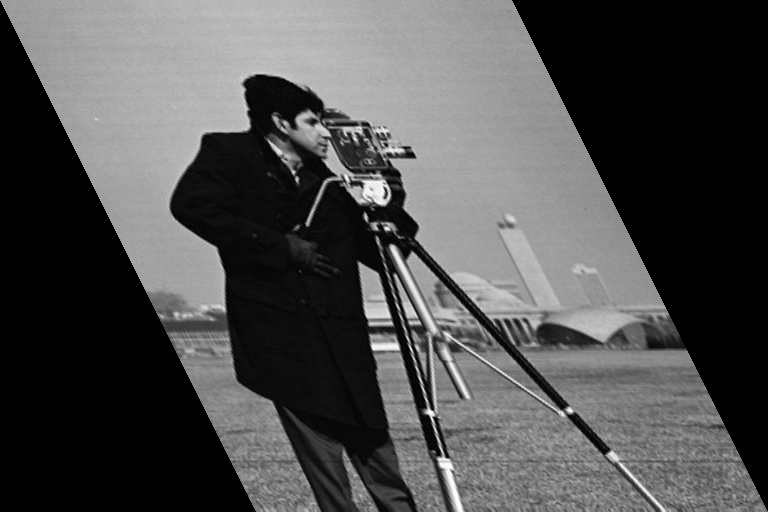

In [34]:
# -- e. Apply the shear transformation ─────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
new_width = int(width + abs(shear_factor) * height)
new_height = height

sheared_image = image.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC
)

display(sheared_image)

In [35]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_image.save("task1_3_sheared.jpg")

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

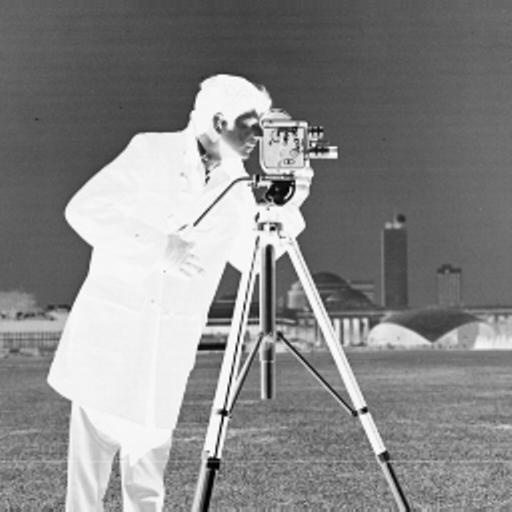

In [36]:
# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation

image_array = np.array(image)
negative_array = 255 - image_array
negative_numpy = Image.fromarray(negative_array.astype(np.uint8))

display(negative_numpy)

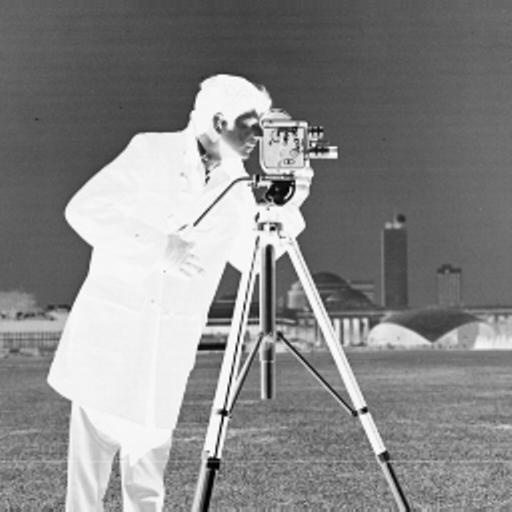

In [38]:
# Method 2: PIL's ImageOps
negative_pil = ImageOps.invert(image)

display(negative_pil)

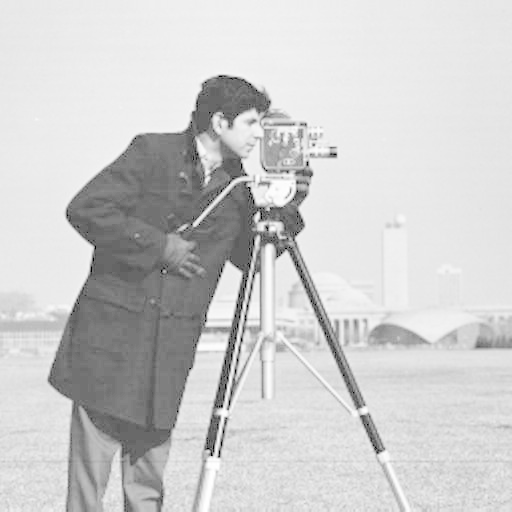

In [39]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
image_array = np.array(image).astype(np.float32)
log_array = c * np.log(1 + image_array)

# Convert to valid 8-bit pixel values
log_array = np.clip(log_array, 0, 255).astype(np.uint8)
log_image = Image.fromarray(log_array)

display(log_image)

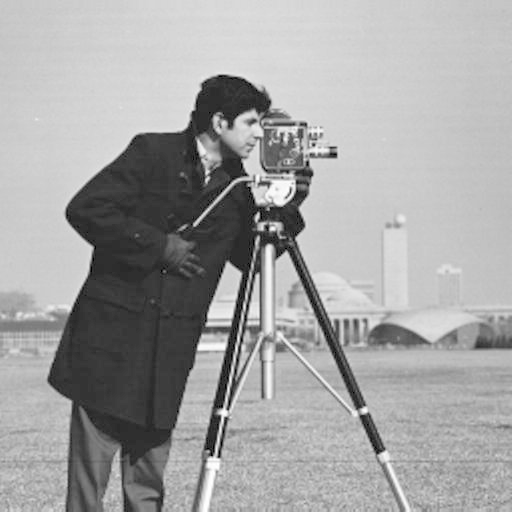

In [40]:
# ── 3. Power-law / Gamma correction ───────────────

gamma = 0.5

normalized = np.array(image).astype(np.float32) / 255.0
gamma_array = np.power(normalized, gamma) * 255.0
gamma_array = np.clip(gamma_array, 0, 255).astype(np.uint8)

gamma_image = Image.fromarray(gamma_array)

display(gamma_image)